In [5]:
# ============================================================
# FinWise Goal Prediction - Final Model Comparison Notebook
# ============================================================
# This notebook:
# 1) Loads the synthetic goal dataset
# 2) Creates a binary goal success label (classification target)
# 3) Trains two models (Random Forest + Logistic Regression)
# 4) Evaluates them using test split + cross-validation
# 5) Visualizes performance (ROC + Precision-Recall curves)
# 6) Interprets Random Forest feature importance
#
# Key point: We explicitly remove leakage features (remaining_amount, required_monthly)
# so the model learns behavior rather than reconstructing the label formula.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

In [6]:
# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv("synthetic_goal_training.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (165000, 26)


,user_id,month,goal_start_month,deadline_month,target_amount,current_amount,remaining_amount,months_left,required_monthly,prev3_avg_savings,...,prev3_expense_ratio,prev3_income_std,prev3_expense_std,prev3_savings_std,lag1_savings,lag2_savings,month_num,month_sin,month_cos,target_savings_ratio
0,USER0001,2022-04,2024-05,2024-12,18971.433447,3794.286689,15177.146757,32,474.285836,1432.740713,...,0.395702,152.388265,106.537967,256.687775,1422.138485,1752.284751,4,8.660254e-01,-0.500000,0.307885
1,USER0001,2022-05,2024-05,2024-12,18971.433447,3794.286689,15177.146757,31,489.585379,1484.111775,...,0.410368,898.318304,1044.060230,198.557922,1277.912088,1422.138485,5,5.000000e-01,-0.866025,0.540732
2,USER0001,2022-06,2024-05,2024-12,18971.433447,3794.286689,15177.146757,30,505.904892,1779.878215,...,0.403822,954.140731,873.341618,610.748684,2639.584071,1277.912088,6,1.224647e-16,-1.000000,0.194388
3,USER0001,2022-07,2024-05,2024-12,18971.433447,3794.286689,15177.146757,29,523.349888,1663.276612,...,0.409205,1102.659026,860.323393,695.436463,1072.333677,2639.584071,7,-5.000000e-01,-0.866025,0.356060
4,USER0001,2022-08,2024-05,2024-12,18971.433447,3794.286689,15177.146757,28,542.040956,1879.565890,...,0.383199,978.243674,362.770090,640.697705,1926.779923,1072.333677,8,-8.660254e-01,-0.500000,0.073207


In [7]:
# ============================================================
# Create Target Variable: goal_success
# ============================================================
# We define goal success as:
#   success = 1 if (recent avg savings * months left) >= remaining amount
#   success = 0 otherwise
#
# IMPORTANT:
# This label is deterministic, so we must avoid including features that
# directly encode the same formula (leakage). We'll handle that next.
# ============================================================

df["goal_success"] = (
    df["prev3_avg_savings"] * df["months_left"]
    >= df["remaining_amount"]
).astype(int)

print(df["goal_success"].value_counts())

goal_success
0    94478
1    70522
Name: count, dtype: int64


In [8]:
# ============================================================
# Define Feature Set (Leakage Removed)
# ============================================================
# Leakage risk features:
# - remaining_amount: directly used in target definition
# - required_monthly: derived as remaining_amount / months_left
#
# If included, the model can "cheat" and reconstruct the label.
#
# We only keep behavioral + historical + time encoding features.
# ============================================================

FEATURES = [
    "months_left",           # Deadline pressure (time remaining)
    "prev3_avg_savings",     # Recent average savings (behavior)
    "prev3_std_savings",     # Savings volatility (behavior stability)
    "prev3_trend",           # Savings trend (improving or worsening)
    "prev3_avg_income",      # Income level signal
    "prev3_avg_expense",     # Expense burden signal
    "prev3_income_std",      # Income stability
    "prev3_expense_std",     # Expense stability
    "lag1_savings",          # Savings last month
    "lag2_savings",          # Savings 2 months ago
    "target_savings_ratio",  # Goal burden relative to income
    "month_sin",             # Seasonal encoding
    "month_cos"              # Seasonal encoding
]

X = df[FEATURES]
y = df["goal_success"]

print("Using features:", FEATURES)
print("X shape:", X.shape, "| y shape:", y.shape)

Using features: ['months_left', 'prev3_avg_savings', 'prev3_std_savings', 'prev3_trend', 'prev3_avg_income', 'prev3_avg_expense', 'prev3_income_std', 'prev3_expense_std', 'lag1_savings', 'lag2_savings', 'target_savings_ratio', 'month_sin', 'month_cos']
X shape: (165000, 13) | y shape: (165000,)


In [9]:
# ============================================================
# Train/Test Split
# ============================================================
# We split to evaluate generalization (performance on unseen data).
# Stratify preserves class balance between train and test.
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (132000, 13) Test: (33000, 13)


In [10]:
# ============================================================
# Model 1: Random Forest Classifier
# ============================================================
# Why Random Forest?
# - Captures nonlinear relationships (common in finance)
# - Robust to skewed distributions and outliers
# - Handles correlated features well
# - No scaling required
# ============================================================

rf = RandomForestClassifier(
    n_estimators=200,   # number of trees
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Predict class labels + probabilities (needed for ROC/PR curves)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print("===== Random Forest Results =====")
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))

===== Random Forest Results =====
              precision    recall  f1-score   support

           0       0.94      0.92      0.93     18896
           1       0.90      0.92      0.91     14104

    accuracy                           0.92     33000
   macro avg       0.92      0.92      0.92     33000
weighted avg       0.92      0.92      0.92     33000

ROC-AUC: 0.9816916628284
Confusion Matrix:
 [[17478  1418]
 [ 1079 13025]]


In [11]:
# ============================================================
# Model 2: Logistic Regression (Baseline)
# ============================================================
# Why Logistic Regression?
# - Strong baseline model for binary classification
# - Helps verify whether the problem is mostly linear
#
# IMPORTANT:
# Logistic Regression requires feature scaling.
# We use a Pipeline so scaling happens correctly and safely.
# ============================================================

log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

log_reg.fit(X_train, y_train)

lr_pred = log_reg.predict(X_test)
lr_prob = log_reg.predict_proba(X_test)[:, 1]

print("===== Logistic Regression Results =====")
print(classification_report(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, lr_pred))

===== Logistic Regression Results =====
              precision    recall  f1-score   support

           0       0.91      0.93      0.92     18896
           1       0.91      0.88      0.89     14104

    accuracy                           0.91     33000
   macro avg       0.91      0.90      0.91     33000
weighted avg       0.91      0.91      0.91     33000

ROC-AUC: 0.9692069748710799
Confusion Matrix:
 [[17623  1273]
 [ 1734 12370]]


In [12]:
# ============================================================
# Cross-Validation (5-fold Stratified)
# ============================================================
# Purpose:
# - Ensures the model performance is not dependent on one random split
# - Measures stability (variance across folds)
#
# We'll compute CV Accuracy and CV ROC-AUC for both models.
# ============================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest CV
rf_cv_acc = cross_val_score(rf, X, y, cv=skf, scoring="accuracy")
rf_cv_auc = cross_val_score(rf, X, y, cv=skf, scoring="roc_auc")

# Logistic Regression CV
lr_cv_acc = cross_val_score(log_reg, X, y, cv=skf, scoring="accuracy")
lr_cv_auc = cross_val_score(log_reg, X, y, cv=skf, scoring="roc_auc")

print("===== Cross-Validation Summary =====")
print("Random Forest CV Accuracy: mean =", rf_cv_acc.mean(), "std =", rf_cv_acc.std())
print("Random Forest CV ROC-AUC:  mean =", rf_cv_auc.mean(), "std =", rf_cv_auc.std())

print("\nLogistic Regression CV Accuracy: mean =", lr_cv_acc.mean(), "std =", lr_cv_acc.std())
print("Logistic Regression CV ROC-AUC:  mean =", lr_cv_auc.mean(), "std =", lr_cv_auc.std())

===== Cross-Validation Summary =====
Random Forest CV Accuracy: mean = 0.9248545454545454 std = 0.0008901872977978909
Random Forest CV ROC-AUC:  mean = 0.9819370053671834 std = 0.00021431223423069477

Logistic Regression CV Accuracy: mean = 0.9099272727272727 std = 0.0006701287515231678
Logistic Regression CV ROC-AUC:  mean = 0.9700699026485251 std = 0.00047910643656719497


In [ ]:
# ============================================================
# Create a comparison table summarizing all results
# ============================================================

results = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression"],
    "Test Accuracy": [
        (rf_pred == y_test).mean(),
        (lr_pred == y_test).mean()
    ],
    "Test ROC-AUC": [
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, lr_prob)
    ],
    "CV Mean Accuracy": [
        rf_cv_acc.mean(),
        lr_cv_acc.mean()
    ],
    "CV Std Accuracy": [
        rf_cv_acc.std(),
        lr_cv_acc.std()
    ],
    "CV Mean ROC-AUC": [
        rf_cv_auc.mean(),
        lr_cv_auc.mean()
    ],
    "CV Std ROC-AUC": [
        rf_cv_auc.std(),
        lr_cv_auc.std()
    ]
})

results

,Model,Test Accuracy,Test ROC-AUC,CV Mean Accuracy,CV Std Accuracy,CV Mean ROC-AUC,CV Std ROC-AUC
0,Random Forest,0.924333,0.981692,0.924855,0.00089,0.981937,0.000214
1,Logistic Regression,0.908879,0.969207,0.909927,0.00067,0.970070,0.000479


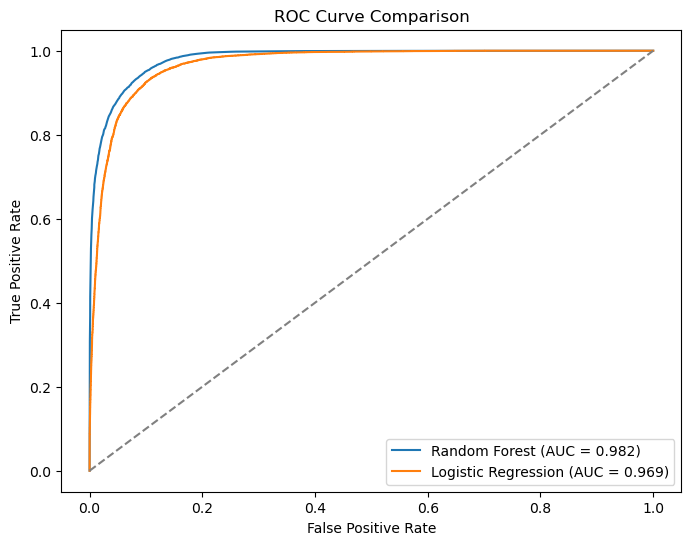

In [14]:
# ============================================================
# ROC Curve Comparison
# ============================================================
# ROC Curve shows how well the model separates success vs failure
# across all thresholds (not just at 0.5).
# Higher curve / higher AUC = better discrimination.
# ============================================================

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)

plt.figure(figsize=(8,6))
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.3f})")
plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, lr_prob):.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

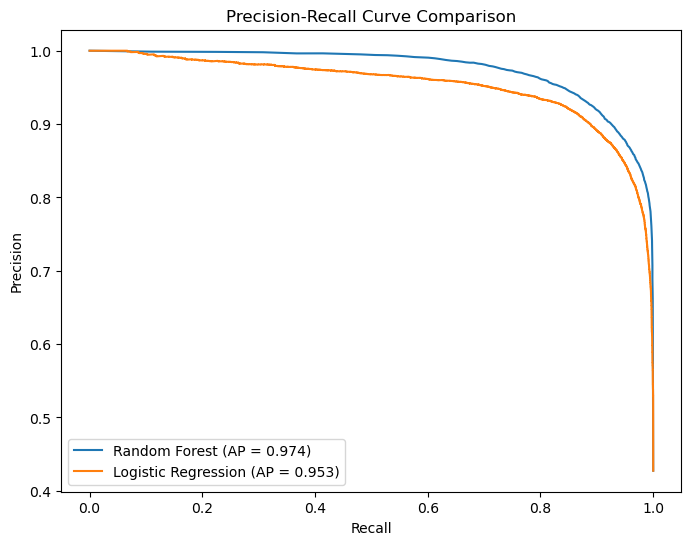

In [15]:
# ============================================================
# Precision-Recall Curve Comparison
# ============================================================
# PR curve is useful when positive class is important and/or imbalanced.
# It shows the tradeoff between catching true positives (recall)
# and being correct when predicting positive (precision).
# ============================================================

rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_prob)
lr_precision, lr_recall, _ = precision_recall_curve(y_test, lr_prob)

plt.figure(figsize=(8,6))
plt.plot(rf_recall, rf_precision, label=f"Random Forest (AP = {average_precision_score(y_test, rf_prob):.3f})")
plt.plot(lr_recall, lr_precision, label=f"Logistic Regression (AP = {average_precision_score(y_test, lr_prob):.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

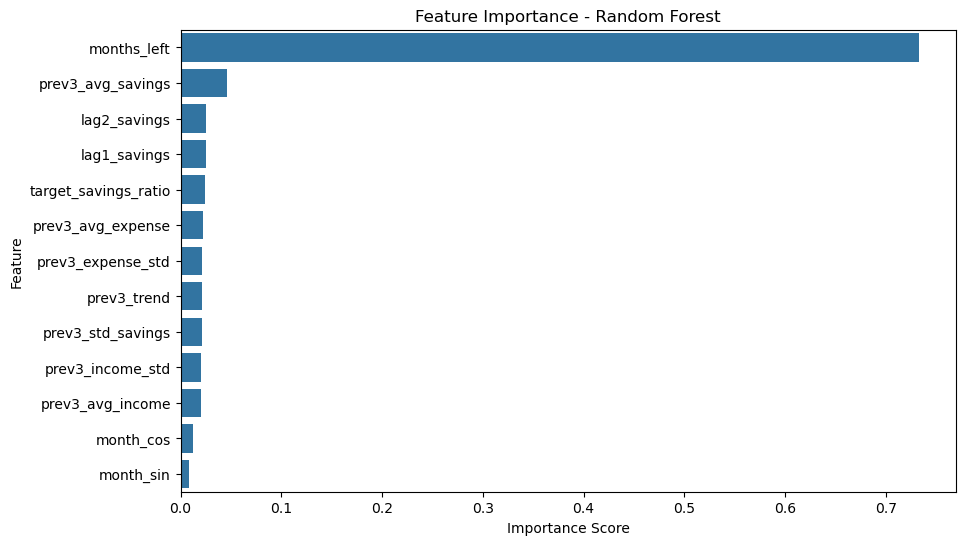

,feature,importance
0,months_left,0.732603
1,prev3_avg_savings,0.045851
9,lag2_savings,0.025426
8,lag1_savings,0.025254
10,target_savings_ratio,0.024184
5,prev3_avg_expense,0.021942
7,prev3_expense_std,0.021375
3,prev3_trend,0.021278
2,prev3_std_savings,0.020863
6,prev3_income_std,0.020604


In [16]:
# ============================================================
# Random Forest Feature Importance
# ============================================================
# This tells us which features the RF model relies on most
# when predicting goal success.
# ============================================================

feature_importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="importance", y="feature", data=feature_importance)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

feature_importance

In [17]:
print("Train ROC-AUC:", roc_auc_score(y_train, rf.predict_proba(X_train)[:,1]))
print("Test ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

Train ROC-AUC: 1.0
Test ROC-AUC: 0.9816916628284
